### Part A
#### A1. 請說明Bag of Words(BoW)的三大缺點，並針對每個確點舉一個具體的中文句子範例說明。
- **Curse of Dimensionality**：詞彙庫越大，向量維度就越高，最終形成巨大的矩陣，耗盡電腦記憶體。 例如：｢期中考要讀一堆書」，可能會被標記成｢期中考｣、｢讀｣、｢書｣等詞彙，但如果詞彙庫中有很多其他詞彙，則向量維度會變得非常大。也就是如果詞彙庫中有10000個詞彙，則每個句子都會被表示為一個10000維的向量，這會導致計算效率低下和記憶體不足的問題。
- **Sparse Vector**：每個句子的向量長度等於整個詞彙庫大小，大多數位置都是 0，造成計算效率極差。
  假設詞彙庫有10000個詞
  句子：「我/不想/考/期中考」(只有4個詞)
  有效資訊比例：$$\frac{4}{10000}=0.03%$$
- **No Semantic Meaning**：BoW把詞和語意全部打亂，導致不同語意的句子可能會出現相同的向量。
  例如：「A贏B」和 「B贏A」語意不一樣但產生的向量完全一樣。
#### A2. TF-IDF 是如何解決「高頻詞不代表重要詞」這個問題的？請以「的」和「蘋果」兩個詞為例，分別計算 TF 與 IDF 的高低，說明 TF-IDF 如何過濾無意義詞。
- **TF-IDF**：詞在文件中出現的次數乘上逆向檔案頻率，可以衡量一個詞的重要程度。
  - TF：
  $$TF\left( i,j\right)=\frac{n_{i,j}}{\sum{_k} n_{k,j}}$$
    - $n_{k,j}$ 表示詞$i$在文件$j$中出現的次數
    - $\sum{_k} n_{k,j}$  表示文件$j$中所有詞的出現次數總和（總字數）
    - 假設的在文件a中出現500次，蘋果1000次，而文件a有10000個詞，根據公式可以得到
  $$
  \begin{align*}
  TF(的,a) &= \frac{500}{10000}=0.02\\
  TF(蘋果,a) &= \frac{1000}{10000}=0.1\\
  \end{align*}
  $$
  - **IDF**:
  $$IDF(i)=\log(\frac{D}{df_{i}})$$
    - $D$ 表示所有文件的總數量
    - $df_{i}$ 表示所有詞i的文件數量
    - 假設總文件數量2000，「的」出現在其中的1600份，而「蘋果」出現在60份文件，則：
   $$
  \begin{align*}
  IDF(的) &= \log(\frac{2000}{1600})\approx0.097\leftarrow 數值較低，不具有代表性\\
  IDF(蘋果) &= \log(\frac{2000}{60})\approx1.522\leftarrow 數值較高，有\red{較高}代表性\\
  \end{align*}
  $$
  - **Result**：
    \begin{array}{c||lcr}
    詞&\text{TF} &\text{IDF}  &\text{TF-IDF}\\
    \hline
    的&0.02&0.097&0.0019\\
    蘋果&0.1&1.522&0.1522\\
    \end{array}
#### A3. 比較 Word2Vec 的 CBOW 與 Skip-gram 兩種架構：（1）說明兩者的輸入與輸出方向差異；（2）各自在什麼情況下表現較好？請各舉一個適用場景。
1. 兩者的輸入與輸出方向差異
   
   ||輸入|輸出|
   |---------|----|-----|
   |CBOW|上下文|預測的中心詞|
   |Skip-gram|中心詞|預測的上下文|

2. 各自在什麼情況下表現較好
   
    |方法|訓練速度|罕見詞處理能力|任務|情景|
    |:------|:------------|:----------|:-------------|:---------|
    |CBOW|較快|一般|大型語料庫|chatbox、日常翻譯|
    |Skip-gram|較慢|較好|小型語料庫和</br>罕見詞多的任務|醫學文獻|
3. 架構圖
   
   <figure style="text-align: center;">
    <img src="https://miro.medium.com/v2/resize:fit:750/format:webp/0*wSaW3N9-pkE1ESCQ">
    <figcaption>圖一：架構圖比較(來源：https://reurl.cc/kplWqx)</figcaption>
  </figure>

#### A4. 靜態詞向量（Word2Vec / GloVe）與情境化詞向量（BERT）最大的差異是什麼？</br>請以「蘋果」這個詞為例，說明為什麼靜態向量無法處理「同詞不同意」的問題，以及 BERT 如何解決它。
1. 差異：靜態詞向量無法根據同詞不同義產生不同的詞向量，情境化詞向量可以動態調整。
2. 舉例：</br>
   「牛頓被蘋果砸」$\leftarrow 水果$</br>
   「蘋果股票大跌」$\leftarrow 科技公司$
3. BERT解決辦法：</br>
   BERT有多層的embedding，用來捕捉語法特徵、語意特徵和任務相關特徵。</br>BERT 基於 Vaswani 等人提出的 Transformer 實作，並採用 encoder 型態而非 decoder 型態。</br>模型利用Self-supervised Learning的機制，在輸入端的資料隨機遮罩，輸出端得到一個sequence並做liner，再softmax後得到一個prediction的vector，這樣的過程讓模型必須要猜測前後文，利用這種雙向機制讓模型不是單純背誦。另外，BERT也會做Next Sentence Prediction(後續實驗發現SOP(Sentence order prediction)較有效果)，在輸出端做YES/NO回答。(data source:https://www.youtube.com/watch?v=gh0hewYkjgo)


#### B1.實作 Bag of Words 與 TF-IDF 向量化

In [ ]:
pip install jieba scikit-learn gensim nltk transformers torch pandas requests

In [ ]:
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import os
import requests
sentences = [
    "我把真心交給妳，笑著說我沒關係",
    "沒關係，我穿山越嶺都想見到妳",
    "傷痕不代表不公平",
    "我們這些努力不簡單",
    "別講想念我，我會受不了這樣",
    "總有些青春永遠無法只用幾行詩描寫",
    "卻不知到底要用幾頁去描述著離別"
]#來源：芒果醬(九彎十八拐、與其愛你)、林俊傑(修練愛情)、周興哲(青春要用幾行詩來寫)

dict_path = "C:/Users/user1/Downloads/dict.txt.big"
url = "https://raw.githubusercontent.com/fxsjy/jieba/master/extra_dict/dict.txt.big"
if not os.path.exists(dict_path):
    print("檔案不存在，開始下載...")
    response = requests.get(url)
    os.makedirs(os.path.dirname(dict_path), exist_ok=True)
    with open(dict_path, 'wb') as f:
        f.write(response.content)
    print("下載完成。")
else:
    print("檔案已存在，跳過下載。")

jieba.set_dictionary(dict_path)
tokenized_corpus=[]
for s in sentences:
       word=" ".join(jieba.cut(s))
       tokenized_corpus.append(word)
       
word_dic=[]
for sentence in tokenized_corpus:
        words_list=sentence.split(" ")
        word_dic.extend(words_list)

   
vocabulary=list(set(word_dic))
v_len=len(vocabulary)

bow_vectors=[]

for sentence in tokenized_corpus:
        words=sentence.split(" ")
        vector=[0]*v_len
        for word in words:
                if word in vocabulary:
                        idx=vocabulary.index(word)
                        vector[idx]+=1  
        bow_vectors.append(vector)
        
#https://ithelp.ithome.com.tw/articles/10228815
tfidf_vectorizer=TfidfVectorizer(sublinear_tf=False, stop_words=None, token_pattern="(?u)\\b\\w+\\b", smooth_idf=True, norm='l2')
#from gemini 這組設定的整體意圖是**「無損保留所有細節」**——不刪減停用詞、不忽略單一字元、採用最直接的線性詞頻，最後透過 L2 正規化將所有文本拉到相同的長度基準，為後續的機器學習模型提供最完整的基礎特徵。
tfidf_matrix=tfidf_vectorizer.fit_transform(tokenized_corpus)
df_tfidf=pd.DataFrame(tfidf_matrix.toarray(),columns=tfidf_vectorizer.get_feature_names_out())
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


df_bow=pd.DataFrame(bow_vectors,columns=vocabulary)
df_tfidf


Building prefix dict from C:\Users\user1\Downloads\dict.txt.big ...
Loading model from cache C:\Users\user1\AppData\Local\Temp\jieba.u601e771dd9c06cce1822a092549497e1.cache


檔案已存在，跳過下載。


Loading model cost 1.000 seconds.
Prefix dict has been built successfully.


,不,不知,交給,代表,傷痕,公平,別講,到底,努力,卻,去,受不了,只用,妳,幾行,幾頁,想,想念,我,我們,我會,把,描寫,描述,有些,永遠,沒關係,無法,用,真心,穿山越嶺,笑,簡單,總,著,要,見到,詩,說,這些,這樣,都,離別,青春
0,0.000000,0.000000,0.331846,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.275461,0.000000,0.000000,0.00000,0.000000,0.470909,0.000000,0.000000,0.331846,0.000000,0.000000,0.000000,0.000000,0.275461,0.000000,0.000000,0.331846,0.00000,0.331846,0.000000,0.000000,0.275461,0.000000,0.00000,0.000000,0.331846,0.000000,0.000000,0.00000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.342277,0.000000,0.000000,0.41234,0.000000,0.292567,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.342277,0.000000,0.000000,0.000000,0.41234,0.000000,0.000000,0.000000,0.000000,0.000000,0.41234,0.000000,0.000000,0.000000,0.000000,0.41234,0.000000,0.000000
2,0.691968,0.000000,0.000000,0.416805,0.416805,0.416805,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
3,0.383337,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.461804,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.461804,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.461804,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.461804,0.000000,0.00000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.426268,0.000000,0.000000,0.000000,0.000000,0.426268,0.000000,0.000000,0.000000,0.000000,0.00000,0.426268,0.302450,0.000000,0.426268,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.426268,0.00000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.333333,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.333333,0.333333,0.000000,0.333333,0.000000,0.000000,0.00000,0.000000,0.000000,0.333333,0.000000,0.000000,0.00000,0.333333,0.000000,0.000000,0.000000,0.00000,0.000000,0.333333
6,0.000000,0.321262,0.000000,0.000000,0.000000,0.000000,0.000000,0.321262,0.000000,0.321262,0.321262,0.000000,0.000000,0.000000,0.000000,0.321262,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.321262,0.000000,0.000000,0.000000,0.000000,0.321262,0.000000,0.00000,0.000000,0.000000,0.000000,0.266675,0.321262,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.321262,0.000000


In [19]:
df_bow

,受不了,有些,公平,這些,永遠,幾行,卻,我,傷痕,這樣,要,描寫,用,青春,都,我們,說,沒關係,把,描述,離別,交給,著,笑,別講,詩,不知,我會,去,幾頁,真心,見到,簡單,到底,穿山越嶺,想念,無法,只用,代表,努力,不,總,妳,想,，
0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,1
2,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0
4,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
5,0,1,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0
6,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0,1,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


$$
        差異比較 =
        \begin{cases}
        BoW,  & \text{只能計算出現過的次數，沒有辦法針對重要字標註} \\
        TF-IDF,&\text{可以識別重要字，例如離別跟著在第七句BoW都是1，而TF-IDF離別佔據較高權重}
        \end{cases}
$$

##### B1程式碼解釋
程式碼分成兩部分，先用`sentence`建立統一的語料庫，並統一使用`jieba`模型進行中文斷詞。第一部分利用`set`和`list`搭配`for迴圈`進行BoW的實作。</br>第二部分先創建`TfidfVectorizer`物件並設定無損保留細節，利用`fit_transform`回傳IF-IDF的值。

#### B2.訓練 Word2Vec 模型並分析詞向量

In [20]:
'''
語料來源：
link1:https://www.lemonde.fr/en/international/article/2026/04/03/iran-vows-crushing-attacks-on-us-after-trump-threats_6752063_4.html#
linK2:https://www.war.gov/News/News-Stories/Article/Article/4450132/trump-objectives-in-iran-near-completion-terrorist-nation-bully-no-longer/
link3:https://www.bbc.com/news/articles/ce8lzd4v7zdo
link4:https://www.cnbc.com/2026/04/03/trump-iran-threats-un-resolution-blocked-strait-of-hormuz-f35-shot-down.html
code reference:
https://ithelp.ithome.com.tw/articles/10367280
https://medium.com/data-science-navigator/%E8%B3%87%E6%96%99%E9%99%8D%E7%B6%AD-t-sne-%E9%99%8D%E7%B6%AD%E8%88%87%E8%A6%96%E8%A6%BA%E5%8C%96-36b4dcfc98d5
'''
import nltk
import requests
from nltk.tokenize import sent_tokenize,RegexpTokenizer
from gensim.models import Word2Vec

nltk.download("punkt")
url = "https://raw.githubusercontent.com/leo2783/NLP_HW2/main/trainingData.txt"
response=requests.get(url)
text=response.text.lower()

raw_sentences=sent_tokenize(text)
corpus=[]
tokenizer = RegexpTokenizer(r'\w+')
corpus=[tokenizer.tokenize(sentences) for sentences in raw_sentences]

model=Word2Vec(corpus,vector_size=100,window=6,min_count=2,sg=1)
similar_word1 = model.wv.most_similar('law', topn=5)
similar_word2 = model.wv.most_similar('operations', topn=5)
similar_word3 = model.wv.most_similar('trump', topn=5)
print("top5向量")
print(similar_word1,'\n',similar_word2,'\n',similar_word3)

result=model.wv.most_similar(positive=['iranian','american'],negative=['iran'])
print("向量運算:",result)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


top5向量
[('a', 0.9923356175422668), ('to', 0.9919193983078003), ('the', 0.99184650182724), ('said', 0.9916152954101562), ('that', 0.9915491342544556)] 
 [('and', 0.9951169490814209), ('the', 0.9946824908256531), ('military', 0.9946122169494629), ('that', 0.9945996999740601), ('a', 0.9944634437561035)] 
 [('the', 0.9979546666145325), ('that', 0.9970345497131348), ('and', 0.9969758987426758), ('of', 0.9968529343605042), ('a', 0.9968057870864868)]
向量運算: [('east', 0.977828860282898), ('post', 0.9760410785675049), ('that', 0.9758085012435913), ('military', 0.9755852222442627), ('energy', 0.9754500389099121), ('s', 0.9753110408782959), ('could', 0.9753051996231079), ('global', 0.9751638770103455), ('war', 0.9751043915748596), ('including', 0.9749698638916016)]


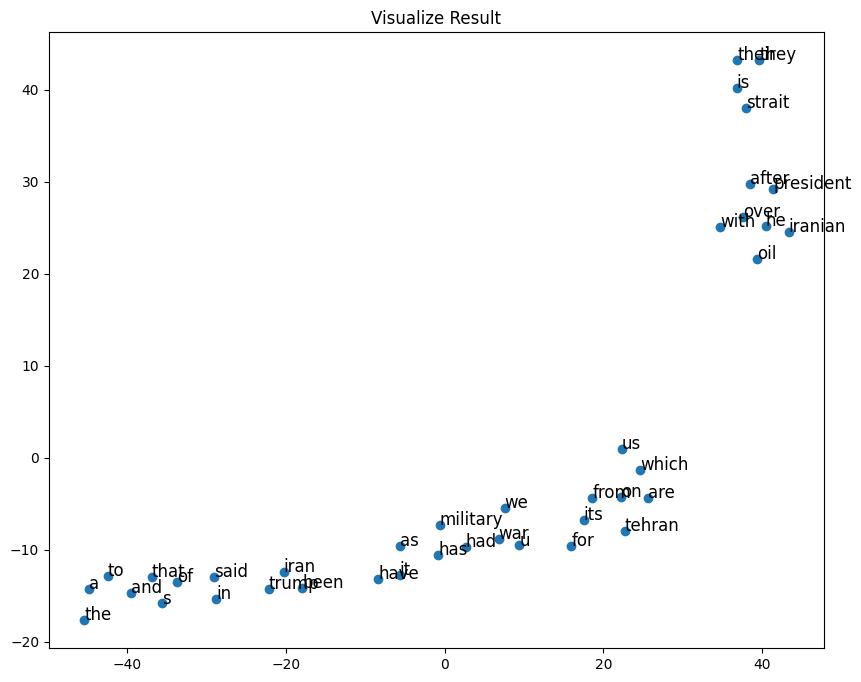

In [21]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

words = model.wv.index_to_key[:40]
vectors = [model.wv[word] for word in words]

tsne_model = TSNE(n_components=2, random_state=42,perplexity=5,init='random', learning_rate='auto')
reduced_vectors = tsne_model.fit_transform(np.array(vectors))

plt.figure(figsize=(10,8))
x_vals=reduced_vectors[:,0]
y_vals=reduced_vectors[:,1]

plt.scatter(x_vals,y_vals)

for i, word in enumerate(words):
    plt.annotate(word, (x_vals[i], y_vals[i]), fontsize=12)
    
plt.title("Visualize Result")
plt.show()

##### B2問題
1. 完成訓練後，找出以下詞的 Top-5 相似詞，並說明結果是否符合語意預期。
   |單字|輸出結果|說明|
   |-----|----|----|
   |law|a,to,said,that,the|原本預期會輸出enforce、government|
   |operations|and,a,the,that,military|算是符合預期，尤其military|
   |trump|the,that,of,and,a|竟然沒有輸出president!!,that和and意料之內，川普很常說|
2. 嘗試至少 一個語意向量運算，例如 A − B + C = ?，並說明運算結果的語意意義。</br>
   伊朗人對於伊朗的關係，相對於美國人對於甚麼。很遺憾結果並沒有美國。

##### B2程式碼解釋
$
\displaystyle
\text{Word2Vec}= 
\begin{cases} 
\text{模型訓練} \\ 
\text{向量輸出} \\ 
\text{畫圖} 
\end{cases}
$
1. 模型訓練
- 語料收集：使用google news搜尋有關於川普和伊朗的消息，複製內文並使用personal github儲存。
- 資料清洗：先將資料轉換成小寫，並使用`nltk`的`sentence_tokenize`和`RegexpTokenizer`完成斷句和斷詞。
- 訓練：載入Word2Vec物件，設定向量大小100，視窗大小6等進行訓練。
2. 向量輸出
- 相似度：利用`model.wv.most_similar()`進行計算。
- 向量運算：利用`model.wv.most_similar()`，並設定`postive`和`negative`。
3. 畫圖
- t-SNE 演算法
  1. 步驟一：將高維資料間轉換成以高斯分佈為相似度的條件機率。
        $$
        p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}
        $$
  2. 步驟二：將要轉換成的低維資料使用 t 分佈為相似度的條件機率。
        $$
        q_{j|i} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq i} (1 + \|y_i - y_k\|^2)^{-1}}
        $$
  3. 步驟三：為了將 1. 2. 之間的機率分佈最相近，最小化所有資料點間的 KL 散度
        $$
        \arg \min D_{KL}(p||q) = \sum_i D_{KL}(p_i||q_i) = \sum_i \sum_j p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}
        $$
  4. 步驟四：以 3. 作為成本函數（Cost Function），並使用隨機梯度下降法（Stochastic Gradient Decent）求最佳解
   $$
        \frac{\partial C}{\partial y_i} = 2 \sum_j (p_{j|i} - q_{j|i} + p_{i|j} - q_{i|j})(y_i - y_j)
        $$
- 參數設定
  - perplexity：
        $$
        Perp(P_i) = 2^{H(P_i)} \qquad H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}
        $$
        困惑度設定越大，此標準差就會越大。</br>
        不確定參數怎麼調，所以調整一個好看且小於`words`大小的。
  - learning_rate：設定auto。
  - ramdom_state：42致敬傳奇，也確保實驗結果相同。</br></br>
  資料轉換成矩陣運算的陣列並降維度。
- 圖的結論：
  可以觀察到單字明顯形成一坨一坨聚集在一起。尤其伊朗和石油的關係相近，一些介詞和be動詞也在一塊。

#### B3.使用預訓練詞向量進行語意相似度分析

In [22]:
'''
reference:
https://ithelp.ithome.com.tw/articles/10346352?sc=rss.qu
'''
import gensim.downloader as api
model = api.load('word2vec-google-news-300')

data=[("dog","cat"),["car","scooter"],("opportunity","chance"),("lose","win"),("empty","full"),
      ("disharmony","unity"),("obligation","glass"),("phone","air"),("commiserate","prone"),("devastation","ruin"),
      ("immediate","distant"),("brochure","ego")]
data = [list(item) for item in data]
sim=[]
for d in data:
      sim.append(model.similarity(d[0],d[1]))
      
cos_df = pd.DataFrame({
    "詞彙 1": [d[0] for d in data],
    "詞彙 2": [d[1] for d in data],
    "餘弦相似度": sim
})

cos_df

,詞彙 1,詞彙 2,餘弦相似度
0,dog,cat,0.760946
1,car,scooter,0.638153
2,opportunity,chance,0.723969
3,lose,win,0.395141
4,empty,full,0.206790
5,disharmony,unity,0.401663
6,obligation,glass,0.024672
7,phone,air,0.045996
8,commiserate,prone,0.115931
9,devastation,ruin,0.264702


##### B3結果分析
- opportunity跟chance居然只有0.72，比dog和cat還低。
- phone跟air不是負相關，推測是apple有推出air之類的。
- 如果詞頻本身比較低，但同義的話，相關度會明顯下降。

##### B3 code分析
利用google的pre-train model，並直接使用gensim的similarity計算餘弦相似度，最後用Dataframe輸出。

#### B4. 【加分題】使用 BERT 實作情境化詞嵌入比較 (+10 分)

In [23]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer=BertTokenizer.from_pretrained('bert-base-uncased')
model=BertModel.from_pretrained('bert-base-uncased')

sentence_1 = "I went to the bank to deposit money."
sentence_2 = "The fish is swimming by the river bank."

inputs_1 = tokenizer(sentence_1, return_tensors="pt")
inputs_2 = tokenizer(sentence_2, return_tensors="pt")

print("Tokens 1:", tokenizer.convert_ids_to_tokens(inputs_1["input_ids"][0]))
print("Tokens 2:", tokenizer.convert_ids_to_tokens(inputs_2["input_ids"][0]))




Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokens 1: ['[CLS]', 'i', 'went', 'to', 'the', 'bank', 'to', 'deposit', 'money', '.', '[SEP]']
Tokens 2: ['[CLS]', 'the', 'fish', 'is', 'swimming', 'by', 'the', 'river', 'bank', '.', '[SEP]']


In [24]:
#https://huggingface.co/learn/llm-course/zh-TW/chapter2/2
#https://docs.pytorch.org/docs/stable/nn.functional.html
#https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.cosine_similarity.html#torch.nn.functional.cosine_similarity
import torch.nn.functional as f
with torch.no_grad():
    outputs_1=model(**inputs_1)
    outputs_2=model(**inputs_2)

print(outputs_1.last_hidden_state.shape)
print(outputs_2.last_hidden_state.shape)

vec1=outputs_1.last_hidden_state[0,5,:]
vec2=outputs_2.last_hidden_state[0,8,:]

print(f.cosine_similarity(vec1,vec2,dim=0,eps=1e-8))

torch.Size([1, 11, 768])
torch.Size([1, 11, 768])
tensor(0.5397)


In [25]:
import gensim.downloader as api
model = api.load('word2vec-google-news-300')
tokenizer = RegexpTokenizer(r'\w+')
sentence_1=tokenizer.tokenize(sentence_1)
sentence_2=tokenizer.tokenize(sentence_2)
similar=model.similarity(sentence_1[4],sentence_2[7])
similar


np.float32(1.0)

##### B4實驗結果
$
\displaystyle
\text{Cosine Similarity}=
\begin{cases} 
0.5397 &\leftarrow\text{BERT} \\ 
1.0 &\leftarrow\text{Word2Vec}
\end{cases}
$ 
- 透過向量的動態調整破除以往單純進行查字典的行為，有效的分辨出語意的不同。

##### B4程式碼解釋
分成三部分：
1. BERT模型載入並張量化
2. 透過`torch.nn.functional`計算cosine similarity
3. 使用Word2Vec並資料處理後計算consine similarity

##### 心得
過程中不只透過gemini的幫助，我也一直上網查詢各種資料，作業內容很有學習力，不過真的太多了。寫了三天。

##### Reference
CSIE 2188 Spring 2026 自然語言處理導論 Ch3 - Word Embedding.pdf</br>
CSIE 2188 Spring 2026 自然語言處理導論 Ch2 - Tokenization (大型語言模型及NLP 最核心的前處理)_Part2.pdf</br>
Gemini對話</br>
https://ithelp.ithome.com.tw/articles/10346352?sc=rss.qu</br>
https://www.lemonde.fr/en/international/article/2026/04/03/iran-vows-crushing-attacks-on-us-after-trump-threats_6752063_4.html#</br>
https://www.war.gov/News/News-Stories/Article/Article/4450132/trump-objectives-in-iran-near-completion-terrorist-nation-bully-no-longer/</br>
https://www.bbc.com/news/articles/ce8lzd4v7zdo</br>
https://www.cnbc.com/2026/04/03/trump-iran-threats-un-resolution-blocked-strait-of-hormuz-f35-shot-down.html</br>
https://ithelp.ithome.com.tw/articles/10367280</br>
https://medium.com/data-science-navigator%E8%B3%87%E6%96%99%E9%99%8D%E7%B6%AD-t-sne-%E9%99%8D%E7%B6%AD%E8%88%87%E8%A6%96%E8%A6%BA%E5%8C%96-36b4dcfc98d5s</br>
https://ithelp.ithome.com.tw/m/articles/10332018</br>
https://ithelp.ithome.com.tw/articles/10228815</br>
芒果醬(九彎十八拐、與其愛你)</br>
林俊傑(修練愛情)</br>
周興哲(青春要用幾行詩來寫)</br>